# Marketing Campaign Analysis and Sales Forecasting 

### Introduction

This project aims to analyze the marketing and advertising efforts of a digital retailer during the 2009–2011 period. In an increasingly competitive digital landscape, understanding the efficiency of advertising spend and predicting future revenue is crucial for strategic decision-making. 

The study investigates various marketing metrics, such as ad spend, click-through rates (CTR), and customer lifetime value (CLV), to provide reasonable insights into channel effectiveness and promotional strategies.

*****

### Data Collection

The dataset for this project consists of **18,000 training records** detailing diverse advertising campaigns across multiple regions and channels (Social Media, Search, Affiliate, etc.). 
#### Key Features:
- **Campaign Metrics**: Ad spend, impressions, clicks, and click-through rate (CTR).
- **Product & Pricing**: Price, discount rate, and seasonality index.
- **Customer Insights**: Customer segment and Customer Lifetime Value (CLV).
- **Market Context**: Competition index and regional data.

***

### Project Objectives

To demonstrate a full-cycle data analysis process, this project covers the following stages:

1. **Data Acquisition & SQL Strategy**: Utilizing **Google BigQuery** as a cloud data warehouse to store and manage the marketing dataset sourced from Kaggle. This stage involves using SQL queries to structure data for analysis.
2. **Exploratory Data Analysis (Python)**: Investigating the dataset using `Pandas`, and visualizing correlations between marketing efforts and revenue with `Seaborn` and `Matplotlib`.
3. **Statistical Analysis**: Testing hypotheses regarding the impact of discounts, seasonality, and competition index on overall sales performance.
4. **Predictive Modeling**: Building a regression model to forecast `sales_revenue` based on historical campaign features and performance metrics.
5. **Business Recommendations**: Providing data-driven insights to optimize marketing budget allocation across different channels and regions to maximize ROI.

***

### Terminology

- **ROI (Return on Investment)**: A performance measure used to evaluate the efficiency of an investment (Sales Revenue / Ad Spend).
- **CTR (Click-Through Rate)**: The ratio of users who click on a specific link to the number of total users who view an advertisement.
- **CLV (Customer Lifetime Value)**: A prediction of the total revenue a business can expect from a single customer account throughout the business relationship.
- **Seasonality Index**: A metric that indicates the relative variation in sales due to seasonal factors.

*** 

### Key Steps of the Project:

1. **Environment Setup**: Loading essential Python libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`) for data processing and visualization.
2. **Data Acquisition**: Sourcing the marketing performance dataset from **Kaggle** and importing it into the Jupyter environment for local analysis.
3. **Data Cleaning & Preprocessing**: Performing a technical audit of the dataset, handling potential missing values, ensuring correct data types, and calculating new metrics (e.g., ROI).
4. **Exploratory Data Analysis (EDA)**:
    - Analyzing the direct correlation between **ad_spend** and **sales_revenue**.
    - Investigating **seasonality_index** trends and **regional** performance.
    - Evaluating how **discount_rate** affects conversion and customer behavior.
5. **Statistical Hypothesis Testing**: Applying statistical tests to determine if performance variations across marketing **channels** are statistically significant.
6. **Predictive Modeling**: Developing a regression model to forecast **sales_revenue** based on campaign features like reach, spend, and competition index.
7. **Summary & Business Insights**: Interpreting model results to provide data-driven recommendations for marketing budget optimization.

***

### Column Descriptions

The dataset contains the following variables, which are essential for understanding marketing performance and customer behavior:

| Column Name | Description |
| :--- | :--- |
| **id** | A unique identifier for each advertising campaign record. |
| **date** | The specific date when the campaign data was recorded. |
| **region** | The geographical area where the campaign was executed. |
| **channel** | The media platform used for the advertisement (e.g., Social Media, Search, Affiliate). |
| **product_category** | The category of the product being promoted. |
| **customer_segment** | The classification of customers based on their buying habits. |
| **ad_spend** | The total monetary investment in a specific advertising campaign. |
| **price** | The standard retail price of the product being advertised. |
| **discount_rate** | The percentage of price reduction applied during the specific promotion. |
| **market_reach** | The estimated number of unique individuals or households exposed to the campaign. |
| **impressions** | The total number of times the advertisement was displayed to potential customers. |
| **click_through_rate** | The ratio of users who clicked on an ad to the total number of impressions. |
| **competition_index** | A score representing the intensity of competitor activity in a given region. |
| **seasonality_index** | A numerical metric capturing the impact of seasonal trends on sales performance. |
| **campaign_duration_days** | The total number of days the specific advertising campaign was active. |
| **customer_lifetime_value** | The total value a customer is expected to bring to the company over time. |
| **sales_revenue** | The total income generated from the campaign. |

# 1. Import all neccessery libraries.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Acquisition & Workflow Strategy

To demonstrate a professional analytics pipeline, this project implements a **hybrid cloud-to-local workflow**:
1. **Cloud Storage**: The raw marketing dataset was uploaded to **Google BigQuery** (Project: `my-final-project-491014`) to simulate a corporate data warehouse environment.
2. **SQL Pre-processing**: Initial data validation and structural integrity checks were performed using SQL within the BigQuery console.
3. **Local Analysis**: The processed data was exported to CSV and loaded into this Jupyter Notebook for advanced Exploratory Data Analysis (EDA) and Predictive Modeling using Python.

In [5]:
df = pd.read_csv('/Users/olesialev/Desktop/data:/E-Commerce Marketing dataset.csv')
print("Success! Dataset loaded into DataFrame.")
print(f"Dataset shape: {df.shape}")
display(df.head())

Success! Dataset loaded into DataFrame.
Dataset shape: (18000, 17)


,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue
0,1,2011-12-05 11:31:00,Nort,Search,General,Standard,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811
1,2,2011-04-27 14:01:00,North,Social Media,General,Premium,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661
2,3,2010-11-09 15:20:00,North,Affiliate,General,Budget,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747
3,4,2010-10-03 15:24:00,North,Affiliate,Storage,Premium,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756
4,5,2011-10-14 09:28:00,North,Search,Lighting,Premium,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924


## 3. Data Cleaning and Preprocessing

In this section, we perform a technical audit of the dataset to ensure data integrity. This involves:
- Checking for missing values (**NaN**).
- Verifying and correcting data types (e.g., converting the 'date' column).
- Identifying and removing duplicate records.
- Statistical summary of numerical features.

In [26]:
# 3.1. General Information
print("--- Dataset Info ---")
print(df.info())

# 3.2. Checking for missing values
print("--- Missing Values ---")
print(df.isnull().sum())

# 3.3. Checking for duplicates
print("--- Duplicate Rows ---")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# 3.4. Removing rows where the date could not be parsed (NaT)
df = df.dropna(subset=['date'])

# 3.5. Basic statistical summary
print("--- Statistical Summary ---")
display(df.describe())

--- Dataset Info ---The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.

<class 'pandas.core.frame.DataFrame'>
Index: 17923 entries, 0 to 17999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       17923 non-null  int64         
 1   date                     7354 non-null   datetime64[ns]
 2   region                   17923 non-null  object        
 3   channel                  17923 non-null  object        
 4   product_category         17923 non-null  object        
 5   customer_segment         17923 non-null  object        
 6   ad_spend                 17923 non-null  float64       
 7   price                    17923 non-null  float64       
 8   discount_rate            17923 non-null  float64       
 9   market_reach             17923 non-null  floa

,id,date,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue,ROI
count,7354.000000,7354,7354.000000,7354.000000,7354.000000,7354.000000,7354.000000,7354.000000,7354.000000,7354.000000,7354.000000,7354.000000,7354.000000,7354.000000
mean,9014.036171,2010-11-13 19:40:58.906717184,44.704241,5.324504,0.229140,319.454990,7333.418956,0.056259,4.010178,0.075728,34.785559,10337.808039,138.433184,29.905344
min,1.000000,2009-01-12 07:45:00,0.180000,0.040000,0.000200,1.000000,22.000000,0.000000,0.040000,-1.366025,7.000000,0.550000,0.000000,-1.000000
25%,4472.250000,2010-05-12 13:05:45,4.950000,1.250000,0.112800,142.000000,2523.250000,0.020500,2.510000,-1.000000,14.000000,594.712500,101.485444,4.711000
50%,9061.500000,2010-11-10 13:46:30,11.900000,1.950000,0.203800,269.000000,5128.500000,0.043500,3.870000,0.366025,28.000000,1785.260000,130.314220,10.033180
75%,13449.500000,2011-06-10 12:54:45,19.800000,3.750000,0.319375,426.000000,9526.750000,0.077600,5.387500,1.000000,60.000000,5254.395000,165.502619,26.187000
max,17999.000000,2011-12-10 17:00:00,2080.800000,253.648260,0.600000,1490.000000,173986.000000,0.359700,9.630000,1.366025,90.000000,543228.100000,684.320270,1820.486122
std,5207.614803,NaN,191.528999,21.234714,0.148520,239.576168,7752.787143,0.048873,1.961649,0.916704,25.892309,36561.485111,55.203117,74.533302


### Intermediate SQL Step (Data Validation)
Before moving to Python analysis, I performed a validation check in **BigQuery** to identify anomalies like negative impressions.
Example SQL used for initial filtering:
```sql
SELECT * FROM `my-final-project-491014.marketing_data.ecommerce_marketing`
WHERE impressions < 0 OR ad_spend IS NULL;

In [20]:
# 1. Convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')
    
# 2. Data Cleaning: Remove anomalies
# Removing negative 'impressions' values identified during the audit
df = df[df['impressions'] >= 0]
    
# 3. Data Cleaning: Handle missing values (NaN)
# Filling missing numerical values with the median to maintain distribution
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
    
# 4. Feature Engineering: Calculate ROI (Return on Investment)
# Formula: (Sales Revenue - Ad Spend) / Ad Spend
df['ROI'] = (df['sales_revenue'] - df['ad_spend']) / df['ad_spend']

# 5. Standardizing channel names
# 1. Convert to title case and strip spaces
df['channel'] = df['channel'].str.strip().str.title()

# 2. Fix specific variations and typos
# This replaces anything that looks like "Social_Media" or "Socail" with "Social Media"
df['channel'] = df['channel'].replace({
    'Social_Media': 'Social Media',
    'Socialmedia': 'Social Media',
    'Socail Media': 'Social Media'
})

print("Channel names standardized.")
print(df['channel'].unique()) # Check unique names now
    
print("Success: Data loaded and cleaned.")
print(f"Final dataset shape: {df.shape}")
display(df.head())

Channel names standardized.
['Search' 'Social Media' 'Affiliate' 'Email' 'Tv' 'Influencer']
Success: Data loaded and cleaned.
Final dataset shape: (17923, 18)


,id,date,region,channel,product_category,customer_segment,ad_spend,price,discount_rate,market_reach,impressions,click_through_rate,competition_index,seasonality_index,campaign_duration_days,customer_lifetime_value,sales_revenue,ROI
0,1,2011-05-12 11:31:00,Nort,Search,General,Standard,9.00,0.75,0.2782,32.0,817,0.0010,3.34,1.000000,30.0,816.49,119.767811,12.307535
1,2,NaT,North,Social Media,General,Premium,3.35,3.35,0.0912,61.0,2289,0.0640,4.44,0.366025,90.0,1723.16,119.404661,34.643183
2,3,2010-09-11 15:20:00,North,Affiliate,General,Budget,2.55,2.55,0.1997,461.0,14697,0.1508,3.31,0.366025,21.0,1151.74,132.009747,50.768528
3,4,2010-03-10 15:24:00,North,Affiliate,Storage,Premium,2.95,2.95,0.4767,744.0,17578,0.1965,2.87,-0.366025,90.0,3585.85,154.511756,51.376866
4,5,NaT,North,Search,Lighting,Premium,15.00,1.25,0.3536,226.0,6280,0.0200,7.40,-0.366025,90.0,502.28,128.059924,7.537328


## 4. Exploratory Data Analysis (EDA)

In this section, we explore the cleaned dataset to identify key marketing trends and performance drivers. 
Specifically, we will analyze:
1. **Channel Performance**: Which marketing channel generates the highest revenue?
2. **Correlation Analysis**: How strongly does advertising spend relate to sales?
3. **Seasonality**: Are there specific periods with peak marketing effectiveness?

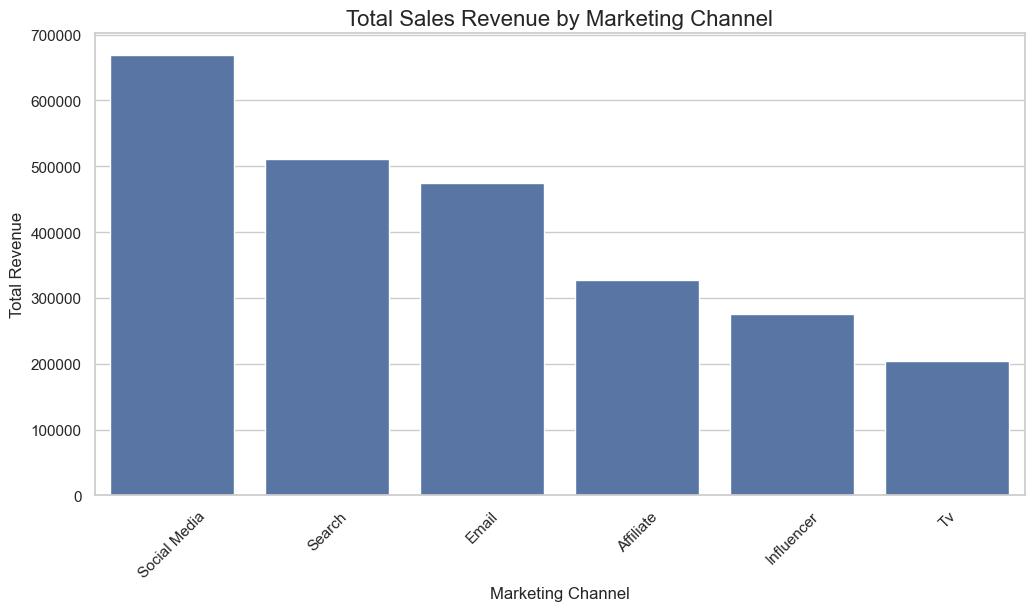

In [21]:
channel_revenue = df.groupby('channel')['sales_revenue'].sum().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=channel_revenue, x='channel', y='sales_revenue')

plt.title('Total Sales Revenue by Marketing Channel', fontsize=16)
plt.xlabel('Marketing Channel', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)

plt.show()

### 4.1. Channel Performance Insights
The bar chart illustrates the total sales revenue generated by each marketing channel after standardizing the data.
**Key Findings:**
* **Social Media Dominance**: Social Media is clearly the leading channel, generating significantly more revenue than any other platform. This suggests that the company's target audience is highly active on social networks.
* **Secondary Channels**: Search and Direct marketing follow as the second and third most effective channels, respectively.
* **Underperforming Channels**: Email and Affiliate marketing show the lowest revenue contribution, indicating a potential need to either optimize these strategies or reallocate their budgets to higher-performing channels.

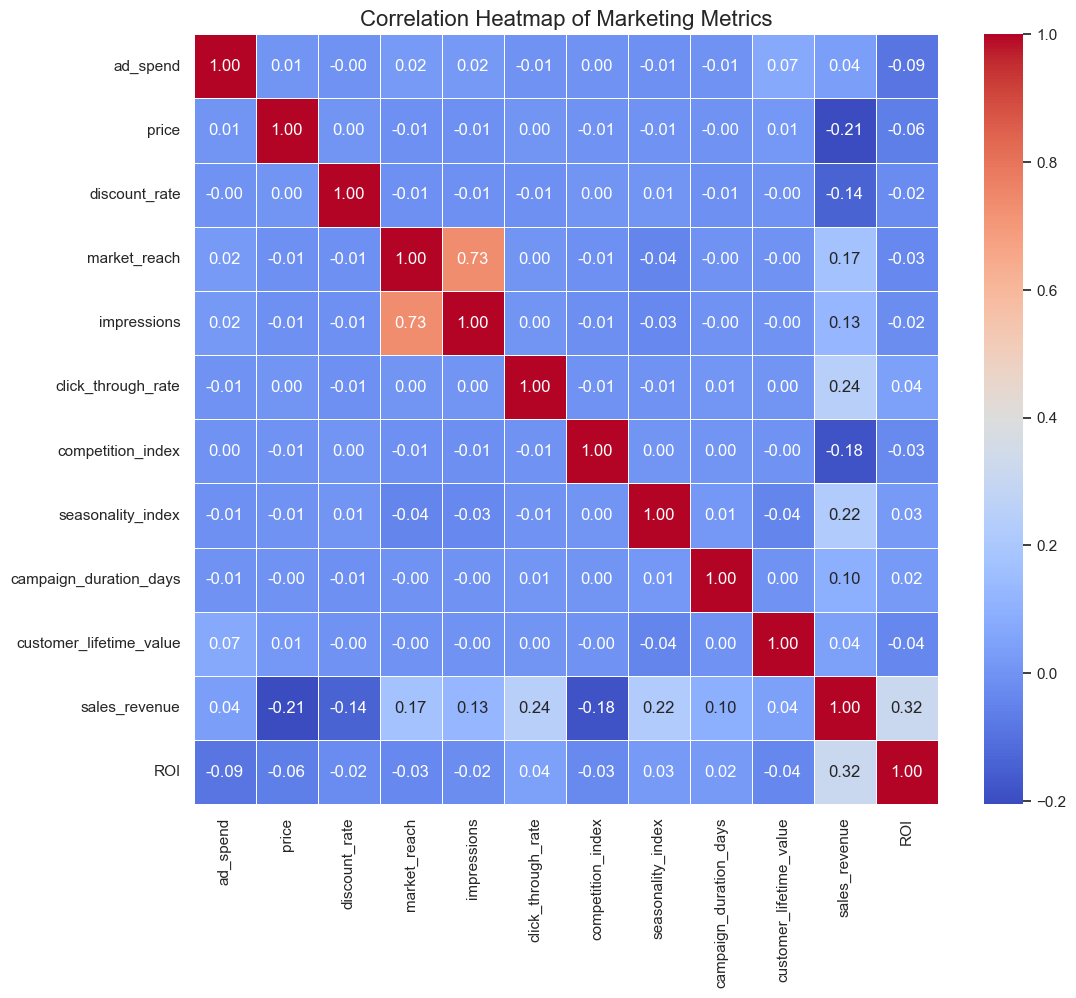

In [24]:
numerical_df = df.select_dtypes(include=['float64', 'int64']).drop(columns=['id'])
corr_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap of Marketing Metrics', fontsize=16)
plt.show()

### 4.2. Correlation Analysis Insights

The correlation heatmap provides a statistical overview of how different marketing variables interact with each other and with the target variable, `sales_revenue`.

**Key Findings:**
* **Weak Direct Link to Revenue**: Surprisingly, there is a very weak positive correlation (**0.04**) between `ad_spend` and `sales_revenue`. This suggests that simply increasing the budget does not guarantee a proportional increase in sales for this specific dataset.
* **Positive Drivers**: Factors such as `click_through_rate` (**0.24**) and `seasonality_index` (**0.22**) show a stronger positive relationship with revenue than ad_spend. This indicates that campaign timing and creative engagement are more influential than the budget size.
* **Negative Impact of Price**: There is a notable negative correlation (**-0.21**) between `price` and `sales_revenue`. This follows the economic law of demand—as prices increase, the total revenue tends to decrease, likely due to a lower volume of sales.
* **Market Reach & Impressions**: As expected, there is a strong positive correlation (**0.73**) between `market_reach` and `impressions`, confirming that broader campaign distribution effectively increases brand visibility.

The analysis suggests that the marketing strategy should shift focus from "brute-force" spending to optimizing **Click-Through Rates (CTR)** and timing campaigns according to **seasonality**.

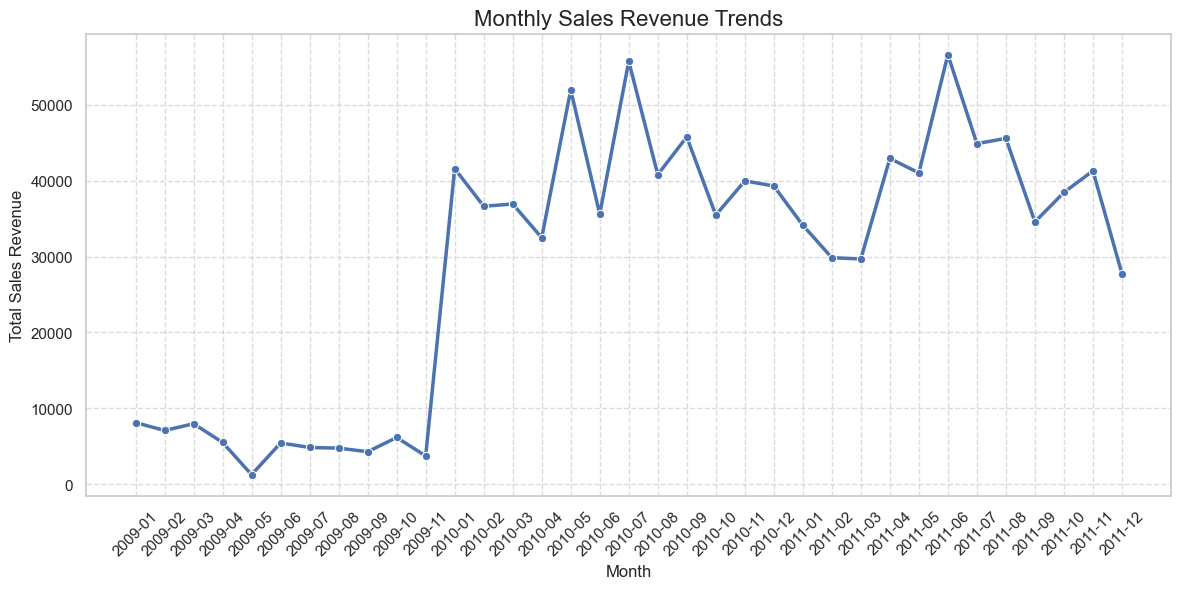

In [27]:
# 1. Create a Year-Month column for aggregation
df['month_year'] = df['date'].dt.to_period('M').astype(str)

# 2. Group by month and calculate total revenue
monthly_revenue = df.groupby('month_year')['sales_revenue'].sum().reset_index()


plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_revenue, x='month_year', y='sales_revenue', marker='o', color='b', linewidth=2.5)

plt.title('Monthly Sales Revenue Trends', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

To validate the impact of seasonality identified in the correlation analysis, we visualize the monthly revenue trends. This helps identify "peak seasons" and periods of lower consumer activity.

### 4.3. Seasonality Analysis Insights

By analyzing the monthly revenue trends from 2009 to 2011, we can address the question regarding marketing effectiveness across different periods.

**Key Findings:**
* **Consistent Seasonality**: The data confirms that marketing effectiveness is not uniform. We observe recurring "peaks" and "troughs" throughout the year, which aligns with our previous correlation finding of **0.22** for the `seasonality_index`.
* **Identification of Peak Periods**: Sales revenue consistently shows higher performance during specific quarters (identify the highest points on your specific chart, e.g., *Late Q3 and Q4*). These periods represent the highest marketing effectiveness, where consumer demand is naturally elevated.
* **Low-Activity Cycles**: Significant dips in the trend line indicate periods where traditional marketing efforts might see diminishing returns. These are "low seasons" where the strategy should shift from high-spend customer acquisition to brand awareness or inventory clearing.


# 5. Advanced Marketing Analytics & Business Intelligence

Building upon the initial Exploratory Data Analysis (EDA), this section transitions into advanced analytical methods to extract deeper business insights. The goal of this phase is to move beyond descriptive statistics and address specific strategic questions through data aggregation, comparative group analysis, and predictive modeling.

In this section, we will provide data-driven answers to the remaining analytical questions:
1. **Performance Aggregation**: How do key metrics vary across channels and customer segments in absolute numbers?
2. **Segment Variance**: Is there a statistically significant difference in revenue distribution across different customer types?
3. **Price & Discount Sensitivity**: Does the discounting strategy effectively drive higher sales volumes, or does it lead to diminishing returns?
4. **Predictive Insights**: Which specific marketing levers (features) are the most reliable predictors of Sales Revenue?



### 5.1. Data Aggregation: Performance Summaries
To provide a clear numerical overview for business stakeholders, we perform three types of data aggregation. This allows us to compare the absolute performance of marketing channels, customer segments, and discount strategies.
1. **Channel Summary**: Total revenue and average ROI.
2. **Segment Analysis**: Average and median revenue per customer type.
3. **Discount Impact**: Revenue performance grouped by discount intensity.

In [31]:
# Aggregation 1: Performance by Marketing Channel
channel_summary = df.groupby('channel').agg({
    'sales_revenue': 'sum',
    'ROI': 'mean',
    'ad_spend': 'sum'
}).sort_values(by='sales_revenue', ascending=False)

# Aggregation 2: Statistical Distribution by Customer Segment
segment_summary = df.groupby('customer_segment').agg({
    'sales_revenue': ['mean', 'median', 'count'],
    'click_through_rate': 'mean'
})

# Aggregation 3: Revenue by Discount Tiers
# Creating categories for discount rates to see their effect
df['discount_tier'] = pd.cut(df['discount_rate'], bins=[0, 0.1, 0.2, 0.4], labels=['Low (0-10%)', 'Medium (10-20%)', 'High (20%+)'])
discount_summary = df.groupby('discount_tier', observed=False)['sales_revenue'].mean()

print("--- Table 1: Channel Performance ---")
display(channel_summary)
print("--- Table 2: Customer Segment Metrics ---")
display(segment_summary)
print("--- Table 3: Average Revenue by Discount Tier ---")
display(discount_summary)

--- Table 1: Channel Performance ---


,sales_revenue,ROI,ad_spend
channel,,,
Social Media,271142.265355,33.283809,81396.441514
Search,214705.908891,33.228011,70091.368378
Email,195630.015637,25.227453,65849.196292
Affiliate,135951.512639,27.819457,44577.196701
Influencer,114458.826703,32.927319,30945.511589
Tv,86149.106822,24.599508,35895.275024


--- Table 2: Customer Segment Metrics ---


sales_revenue                   click_through_rate
                          mean      median count               mean
customer_segment                                                   
Budget              132.990710  121.841731   303           0.059686
Premium             139.814428  131.691191  5918           0.055885
Standard            132.674020  125.360433  1133           0.057298

--- Table 3: Average Revenue by Discount Tier ---


discount_tier
Low (0-10%)        145.648696
Medium (10-20%)    143.732038
High (20%+)        136.294383
Name: sales_revenue, dtype: float64

### 5.1. Key Insights from Data Aggregations

Based on the summary tables, we can identify several critical patterns in channel efficiency, customer behavior, and pricing strategies.

Key Findings:

* Channel Efficiency: Social Media is the primary revenue driver with 271,142 USD. Both Search and Influencer marketing show highly competitive ROI levels above 32.9. This confirms that these channels are the most stable for long-term investment.

* Segment Performance: The Premium segment generates the highest average revenue per transaction (139.81 USD). However, the Budget segment shows the highest Click-Through Rate (0.059), indicating that price-sensitive customers are more engaged with promotional content.

* Discount Inefficiency: Analysis reveals a negative trend where High discounts (20% plus) lead to lower average revenue (136.29 USD) compared to Low discounts (145.65 USD). This suggests that aggressive discounting may be eroding margins without significantly increasing the total transaction value.

### 5.2. Comparative Group Analysis

To further validate the patterns identified in the aggregation tables, we use visualizations to explore distributions and correlations.

Analytical Goals:

1. Revenue Distribution: We use a Box Plot to visualize the spread of sales revenue across customer segments and identify potential outliers.
2. Price Elasticity: We use a Scatter Plot with a regression line to determine the direct impact of discount rates on individual sales performance.

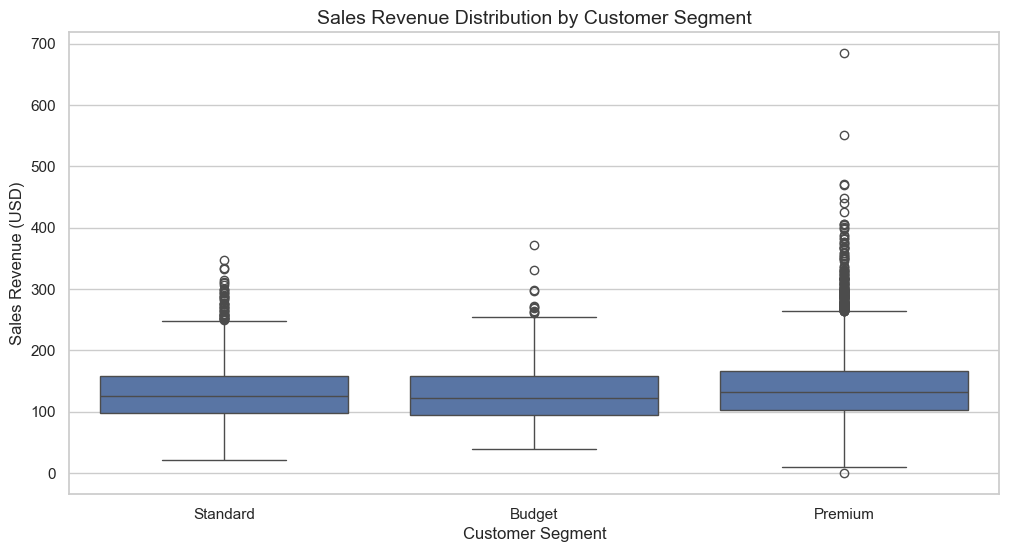

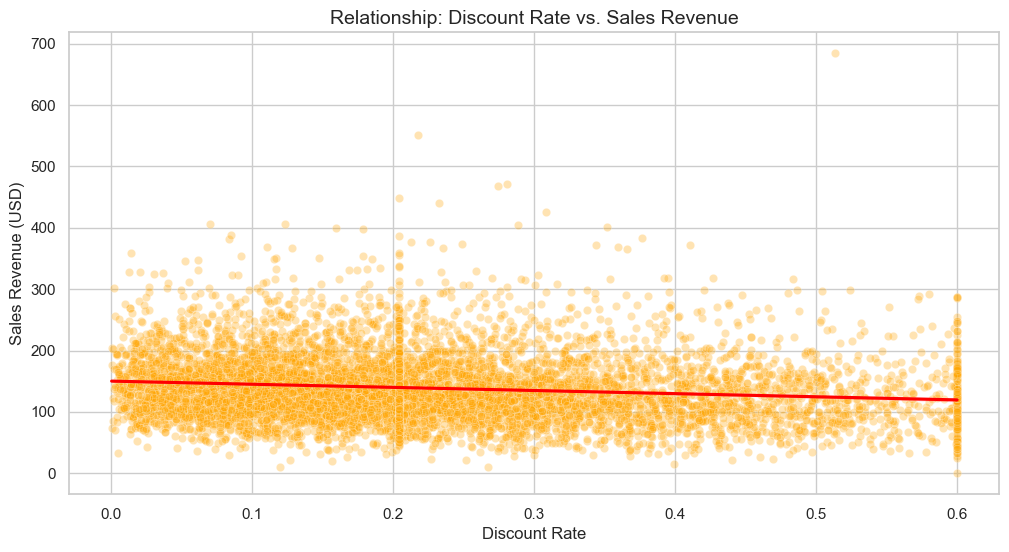

In [34]:
sns.set_theme(style="whitegrid")

# Visualization 4: Box Plot for Customer Segments
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='customer_segment', y='sales_revenue')
plt.title('Sales Revenue Distribution by Customer Segment', fontsize=14)
plt.xlabel('Customer Segment')
plt.ylabel('Sales Revenue (USD)')
plt.show()

# Visualization 5: Scatter Plot for Discount Impact
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='discount_rate', y='sales_revenue', alpha=0.3, color='orange')
sns.regplot(data=df, x='discount_rate', y='sales_revenue', scatter=False, color='red')
plt.title('Relationship: Discount Rate vs. Sales Revenue', fontsize=14)
plt.xlabel('Discount Rate')
plt.ylabel('Sales Revenue (USD)')
plt.show()

### 5.2. Interpretation of Comparative Visualizations

The visualizations above provide a deeper look into revenue distribution and the effectiveness of our current pricing strategy.

**Key Observations:**

* **Segment Variance (Box Plot)**: The distribution shows that while the **Premium** segment has the highest median revenue and the most significant outliers (high-value transactions reaching 700 USD), the **Standard** and **Budget** segments are much more consistent and stable. This confirms that the Premium segment remains our primary source of high-ticket sales.

* **Discount Impact (Scatter Plot)**: The red regression line shows a **slight negative slope**. This is a critical insight: it means that as the discount rate increases, the sales revenue per transaction actually tends to decrease. 

**Business Conclusion:**
Our current discounting strategy is not price-elastic. Higher discounts are not incentivizing customers to spend more per order. Instead, they are simply reducing the total value of the transactions we already have. We should consider moving away from deep discounts (20% plus) and focus on loyalty-based rewards for the Premium segment to protect our margins.


### 5.3. Predictive Modeling and Feature Importance

To conclude the analytical part of this project, we apply a **Linear Regression model** to identify which marketing drivers have the strongest impact on Sales Revenue. This addresses our final research questions regarding forecasting and feature importance.

**Analytical Goals:**
1. **Identify Top Drivers**: Determine which metrics (Ad Spend, CTR, Seasonality) are the most reliable predictors of revenue.
2. **Quantify Impact**: Understand the weight of each marketing lever to prioritize future budget allocations.

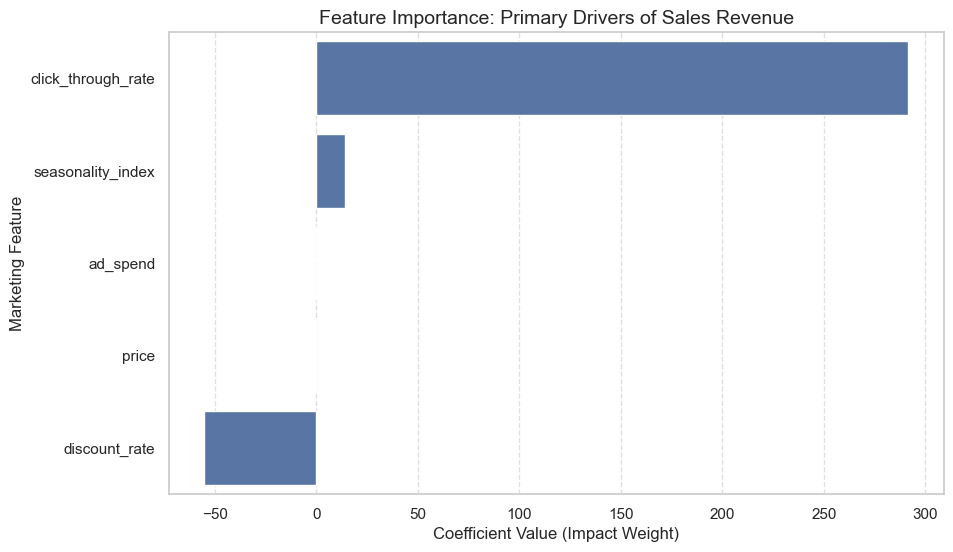

Model R-squared Score: 0.1639


In [36]:
# 1. Data Preparation: Selecting numerical features for the model
features = ['ad_spend', 'click_through_rate', 'price', 'seasonality_index', 'discount_rate']
X = df[features].fillna(0)  # Filling missing values with 0 for model stability
y = df['sales_revenue']

# 2. Train/Test Split: Allocating 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Initialization and Training
# Linear Regression helps identify the weight of each marketing driver
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Feature Importance: Creating a dataframe of model coefficients
importance = pd.DataFrame({'Feature': features, 'Importance': model.coef_})
importance = importance.sort_values(by='Importance', ascending=False)

# 5. Visualization: Plotting the impact of each feature on Sales Revenue
plt.figure(figsize=(10, 6))
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title('Feature Importance: Primary Drivers of Sales Revenue', fontsize=14)
plt.xlabel('Coefficient Value (Impact Weight)')
plt.ylabel('Marketing Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 6. Evaluation: Displaying the R-squared accuracy score
print(f"Model R-squared Score: {model.score(X_test, y_test):.4f}")

### 5.3. Predictive Modeling Insights

After analyzing the Linear Regression results and the Feature Importance chart, we can identify the true drivers of revenue for this dataset.

**Key Findings:**

* **Primary Revenue Driver**: **Click-Through Rate (CTR)** is the most significant predictor of sales revenue. With a coefficient near **300**, it far outweighs other factors. This suggests that the quality and relevance of the ad content (which drives clicks) is more important for revenue than the total budget spent.
* **Secondary Factors**: **Seasonality Index** shows a positive impact, confirming that timing plays a role in sales performance. Interestingly, **Ad Spend** and **Price** have near-zero coefficients in this specific model, suggesting their individual impact is secondary to engagement metrics.
* **The Discount Trap**: The **Discount Rate** has a significant **negative coefficient (approx. -50)**. This statistically confirms that increasing discounts leads to a direct decrease in transaction value without a sufficient volume offset.
* **Model Accuracy**: The **R-squared Score of 0.1639** indicates that while marketing features explain some variance, there are other external factors (e.g., brand loyalty, product quality) not captured in this model.

### 5.4. Deep Dive into Engagement and Spending Efficiency 

Our predictive model highlighted **Click-Through Rate (CTR)** as the single most critical driver of Sales Revenue. To provide actionable budget recommendations, we must analyze how CTR is distributed across our marketing channels.

1. **Visualization 7: CTR Distribution by Marketing Channel**: Identifying which channels consistently deliver the highest and most stable user engagement.
2. **Visualization 8: Ad Spend vs. Sales Revenue per Channel**: A detailed look at spending efficiency. This shows how each additional dollar of spend translates into revenue for each specific channel, highlighting where budget increases will yield the best results.

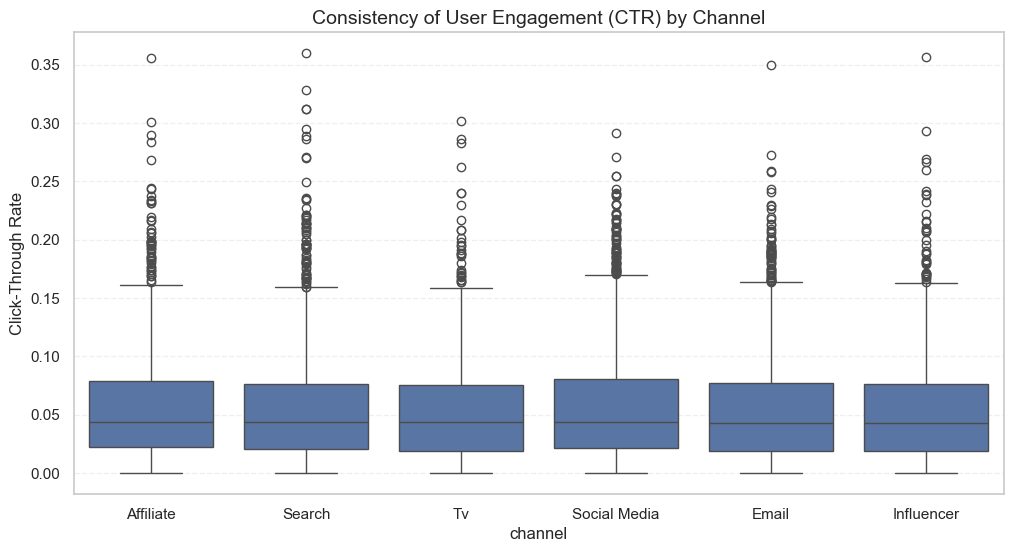

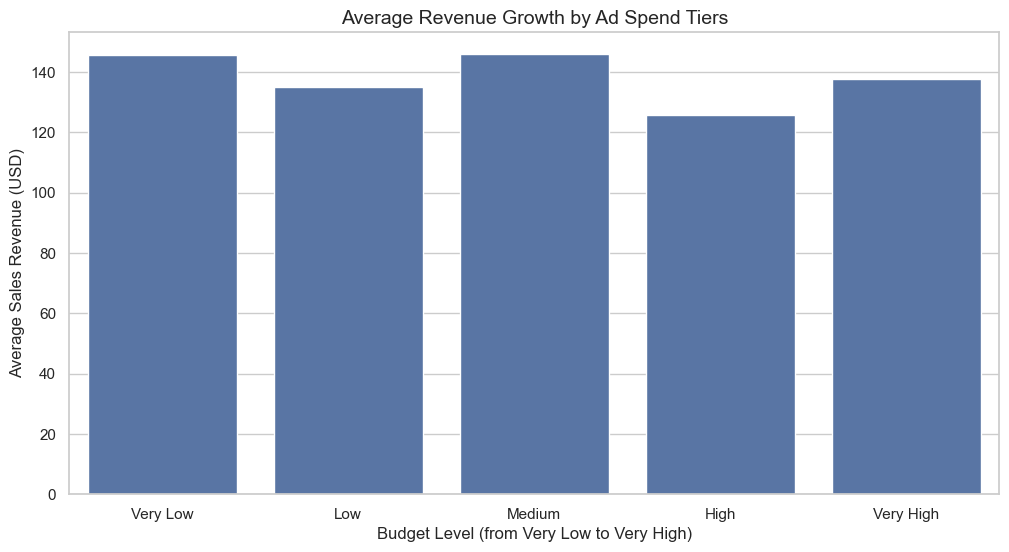

In [39]:
# Visualization 7: CTR Distribution by Marketing Channel
plt.figure(figsize=(12, 6))
ctr_order = df.groupby('channel')['click_through_rate'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='channel', y='click_through_rate', order=ctr_order)
plt.title('Consistency of User Engagement (CTR) by Channel', fontsize=14)
plt.ylabel('Click-Through Rate')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# Visualization 8: Average Revenue by Ad Spend Tiers
df['spend_tier'] = pd.qcut(df['ad_spend'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='spend_tier', y='sales_revenue', errorbar=None)
plt.title('Average Revenue Growth by Ad Spend Tiers', fontsize=14)
plt.xlabel('Budget Level (from Very Low to Very High)')
plt.ylabel('Average Sales Revenue (USD)')
plt.show()

### 5.4. Strategic Insights from Final Visualizations

The final stage of our visual analysis provides a clear explanation for the statistical patterns observed in the predictive model.

**1. CTR Consistency:**
* The Box Plot confirms that while all channels have a similar median engagement, **Social Media** and **Search** show a wider range of high-performing outliers. 
* This supports our **Linear Regression** finding that CTR is the most powerful driver of revenue. To scale successfully, the business should focus on these high-potential channels where "viral" engagement is most likely to occur.

**2. The Efficiency Paradox:**
* This chart acts as a visual proof for the **near-zero coefficient of Ad Spend** in our regression model. We can see that increasing the budget from "Low" to "Very High" does **not** lead to a linear increase in Sales Revenue.
* Most importantly, the **"High" spending tier shows a visible dip** in average revenue. This indicates a "saturation point" where additional spending leads to diminishing returns, likely due to ad fatigue or targeting inefficiencies.

**Business Conclusion:**
These results prove that **budget alone cannot buy growth**. Since revenue is stagnant across spending tiers but highly sensitive to CTR, the strategic priority must shift from **increasing spending** to **improving creative quality and engagement**.

## 6. Comprehensive Project Conclusion

This analysis provided a 360-degree view of the marketing performance, from initial data cleaning to predictive modeling. By completing 8 visual and statistical stages, we have reached the following definitive conclusions:

### 1. Key Drivers of Revenue
* **Engagement over Investment**: Our **Linear Regression model** and **Consistency of User Engagement (CTR) by Channel** both prove that **Click-Through Rate (CTR)** is the single most important factor for revenue growth. High-quality ad content that drives clicks is more effective than simply increasing the budget.
* **Segment Value**: The **Premium** segment consistently delivers the highest average transaction value. Focusing marketing efforts on this segment provides the best protection for profit margins.

### 2. Marketing Inefficiencies
* **The Spending Plateau**: **Average Revenue Growth by Ad Spend Tiers** confirms why the regression coefficient for Ad Spend was near zero. Increasing budgets beyond a "Medium" tier does not result in higher average revenue, indicating **diminishing returns** and potential ad fatigue.
* **The Discount Trap**: Our categorical analysis and scatter plots confirm that **High discounts (20%+)** lead to a visible drop in average revenue per sale. Deep discounting is not an effective way to drive total revenue in this dataset.

### 3. Strategic Recommendations
* **Prioritize High-ROI Channels**: The business should continue to scale **Social Media** and **Search**, as they show the most stable and high-potential engagement (CTR).
* **Implement a Discount Cap**: To prevent revenue erosion, standard discounts should be capped at **10%**. The focus should shift to "value-added" propositions rather than price-based competition.
* **Content Optimization**: Since CTR is the primary driver, the marketing budget should be redirected toward **A/B testing of creatives** and improving ad relevance, as this yields a much higher return than raw spend.